In [1]:
import os
import mne
import numpy as np

# 1. SET YOUR PATH
base_dir = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data/S_13"

def probe_data(path):
    # Find the first .mff folder
    mff_files = [f for f in os.listdir(path) if f.endswith('.mff')]
    
    if not mff_files:
        print("❌ No .mff files found. Check your base_dir path.")
        return

    sample_file = mff_files[0]
    full_path = os.path.join(path, sample_file)
    
    print(f"--- PROBING FILE: {sample_file} ---")
    
    # Check internal folder structure
    print("\n1. Internal Folder Structure (Looking for signal files):")
    internal_contents = os.listdir(full_path)
    for item in sorted(internal_contents):
        size = os.path.getsize(os.path.join(full_path, item)) / (1024**2) # Size in MB
        print(f"   - {item} ({size:.2f} MB)")

    # Try loading with MNE
    print("\n2. MNE Metadata:")
    try:
        raw = mne.io.read_raw_egi(full_path, preload=False, verbose=False)
        print(f"   - Sampling Rate: {raw.info['sfreq']} Hz")
        print(f"   - Number of Channels: {len(raw.ch_names)}")
        print(f"   - Channel Names (First 10): {raw.ch_names[:10]}")
        
        # Check Annotations/Events
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        print(f"\n3. Detected Event IDs (This is crucial for your 'directions'):")
        if event_id:
            for key, val in event_id.items():
                count = np.sum(events[:, 2] == val)
                print(f"   - ID: '{key}' | Occurrences: {count}")
        else:
            print("   - No events/annotations found in this file!")
            
    except Exception as e:
        print(f"❌ Error reading with MNE: {e}")

probe_data(base_dir)

--- PROBING FILE: VI_S13_S1_B2_20251114_115832.mff ---

1. Internal Folder Structure (Looking for signal files):
   - Contents (0.00 MB)
   - Events_ECI TCP-IP 55513.xml (0.02 MB)
   - _launchMFF.lch (0.00 MB)
   - coordinates.xml (0.03 MB)
   - epochs.xml (0.00 MB)
   - info.xml (0.00 MB)
   - info1.xml (0.01 MB)
   - log_VI_S3_S1_B2_20251114_115832.txt (0.04 MB)
   - recordingSettings.xml (0.09 MB)
   - sensorLayout.xml (0.04 MB)
   - signal1.bin (83.16 MB)
   - subject.xml (0.00 MB)
   - techNote.rtf (0.00 MB)
   - workspace.plist (0.02 MB)

2. MNE Metadata:
   - Sampling Rate: 500.0 Hz
   - Number of Channels: 154
   - Channel Names (First 10): ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10']

3. Detected Event IDs (This is crucial for your 'directions'):
   - ID: 'BLCE' | Occurrences: 1
   - ID: 'BLCS' | Occurrences: 1
   - ID: 'BLOE' | Occurrences: 1
   - ID: 'BLOS' | Occurrences: 1
   - ID: 'IEBA' | Occurrences: 3
   - ID: 'IEBY' | Occurrences: 3
   - ID: 'IEDO' | O

## Visualization for event marker duration:

Reading EGI MFF Header from /Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data/S119/VI_S9_S1_B1_A_20251119_061551.mff...
    Reading events ...
    Assembling measurement info ...
    Excluding events {} ...
Reading 0 ... 168994  =      0.000 ...   337.988 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('BLCE'), np.st

/var/folders/5w/wh2htgh56v7ft_7nm78v3rdm0000gn/T/ipykernel_64316/3151311878.py:22: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  mne.viz.plot_events(events, sfreq=raw.info['sfreq'], first_samp=raw.first_samp, event_id=event_id)


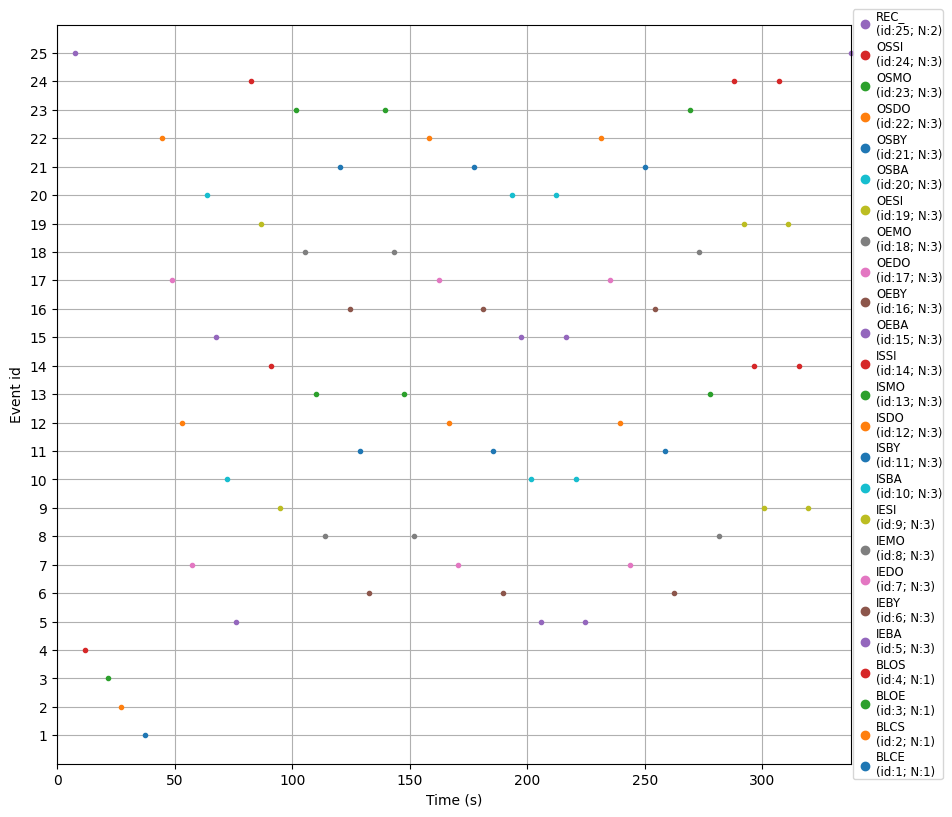

Not setting metadata
3 matching events found
Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 3 events and 3001 original time points ...
0 bad epochs dropped
Plotting 6 seconds of signal for ISBA...
Using matplotlib as 2D backend.


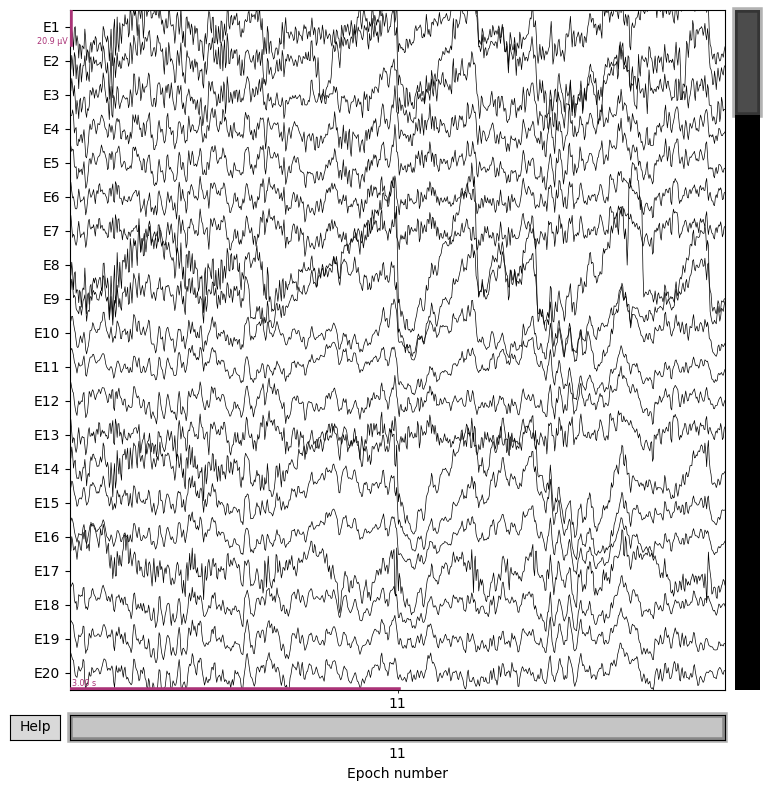

In [2]:
import mne
import matplotlib.pyplot as plt
import os

# 1. Setup paths
# base_dir = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data/S_13"
# mff_files = [f for f in os.listdir(base_dir) if f.endswith('.mff')]
# file_path = os.path.join(base_dir, mff_files[0]) # Checking the first file

file_path = "/Users/kavinfidel/Desktop/GNN+CNS+Hopf/CNS_Lab/VM_EEG/Data/S119/VI_S9_S1_B1_A_20251119_061551.mff"
# 2. Load and Basic Preprocess (to make the signal readable)
raw = mne.io.read_raw_egi(file_path, preload=True)
raw.filter(l_freq=1.0, h_freq=40.0) # Wider filter for visualization
raw.set_eeg_reference('average')

# 3. Extract Events
events, event_id = mne.events_from_annotations(raw)

# --- VISUALIZATION 1: THE TIMELINE ---
# This shows you the distance between markers like 'ISBA' and the next marker.
print("Plotting the event timeline...")
mne.viz.plot_events(events, sfreq=raw.info['sfreq'], first_samp=raw.first_samp, event_id=event_id)
plt.show()

# --- VISUALIZATION 2: SIGNAL DURATION CHECK ---
# We pick one class (e.g., ISBA) and plot 6 seconds to see the "tail end"
event_to_check = 'ISBA' 
if event_to_check in event_id:
    epochs = mne.Epochs(
        raw, events, event_id[event_to_check], 
        tmin=-0.5, tmax=5.5, # We look slightly before and after your 5s window
        baseline=(None, 0), 
        preload=True
    )
    
    # Plot the first trial of this class
    # Look for where the signal "burst" ends or where the next marker appears
    print(f"Plotting 6 seconds of signal for {event_to_check}...")
    epochs[0].plot(scalings='auto', title=f"Check Duration: {event_to_check}")
else:
    print(f"Marker {event_to_check} not found. Available: {event_id.keys()}")

In [ ]:
!pip install scikit-learn

In [1]:
import matplotlib.pyplot as plt

In [18]:
import numpy as np

In [2]:
import mne

In [3]:
from mne.preprocessing import ICA

In [4]:
import os

In [5]:
file = mne.io.read_raw_egi("/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/Data/S5/S5_S1_B1_1640_161025_20251016_044052.mff",preload = True)

Reading EGI MFF Header from /Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/Data/S5/S5_S1_B1_1640_161025_20251016_044052.mff...
    Reading events ...
    Assembling measurement info ...
    Excluding events {} ...
Reading 0 ... 161029  =      0.000 ...   322.058 secs...


In [ ]:
file.ch_names

In [6]:
file.notch_filter(freqs=[50])  # use [50, 100] if harmonics exist


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)



<RawMff | signal1.bin, 152 x 161030 (322.1 s), ~186.9 MiB, data loaded>

In [7]:
file.filter(l_freq=1., h_freq=60.)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 60.00 Hz
- Upper transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 67.50 Hz)
- Filter length: 1651 samples (3.302 s)



<RawMff | signal1.bin, 152 x 161030 (322.1 s), ~186.9 MiB, data loaded>

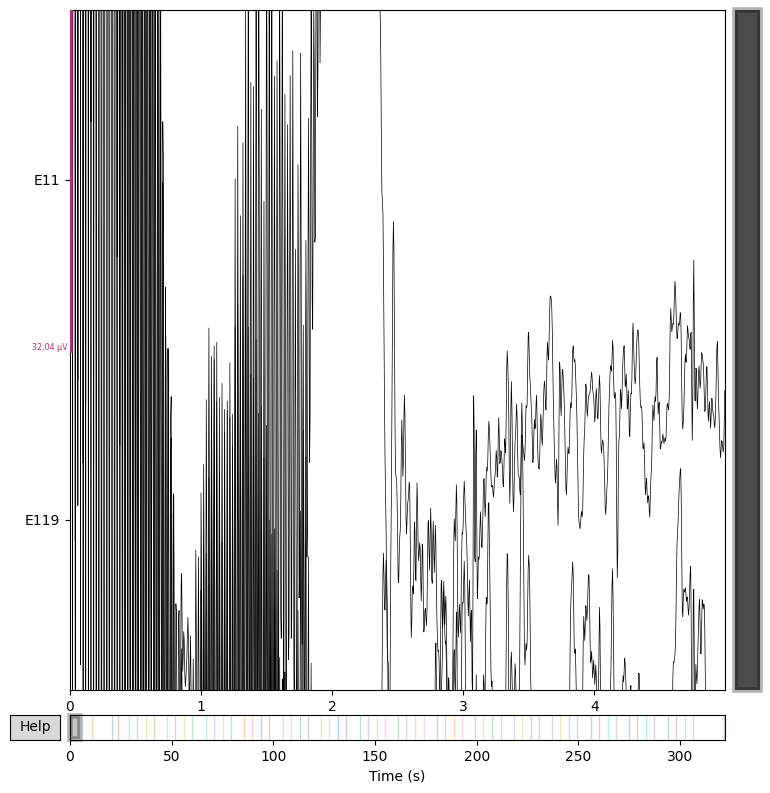

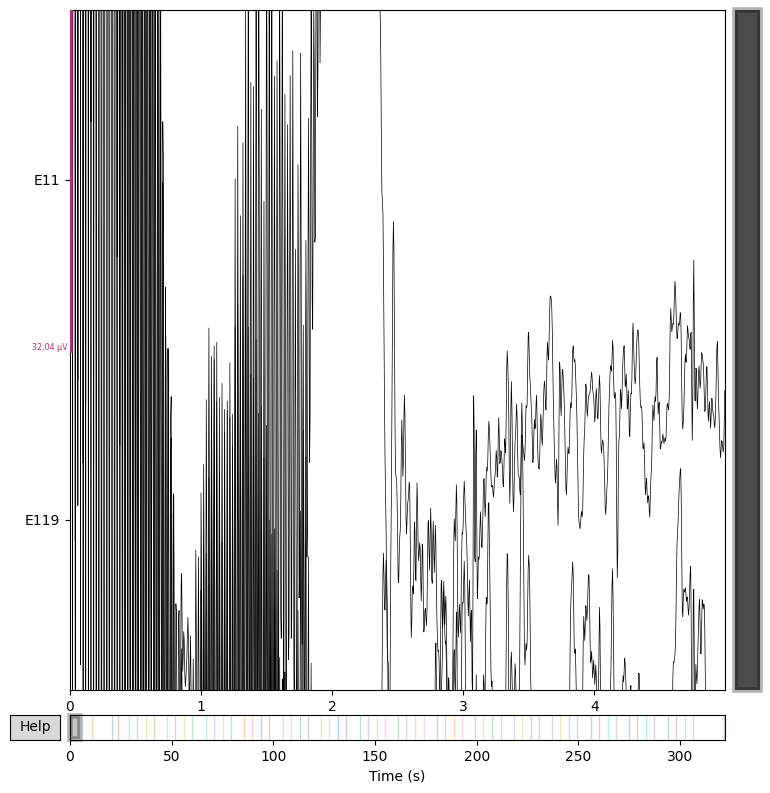

In [10]:
channels = ['E11', 'E119']
file.plot(picks = channels, show = True, scalings = 'auto', duration = 5)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/.venv/lib/python3.13/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


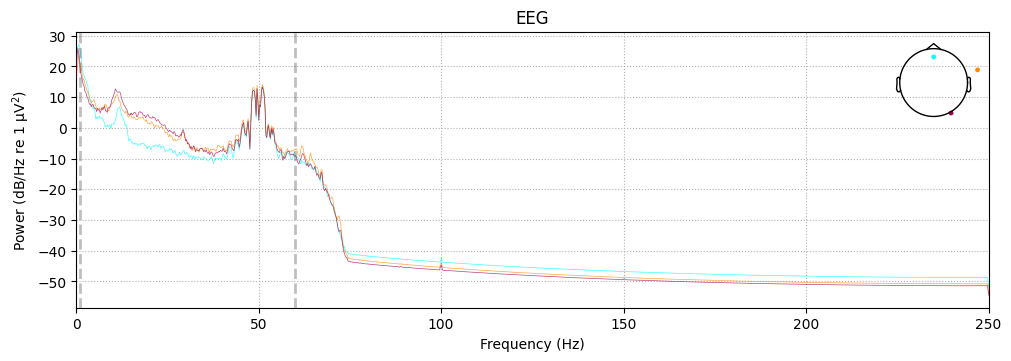

In [21]:
file.plot_psd(picks=['E11', 'E119', 'E94'])


In [19]:

data = file.get_data(picks='eeg')  # shape: (n_channels, n_times)
variances = np.var(data, axis=1)

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(variances, 'o-')
plt.title('Channel variance')
plt.xlabel('Channel index')
plt.ylabel('Variance')

# Flag channels with extremely high variance (e.g., > mean + 3*std)
threshold = np.mean(variances) + 3 * np.std(variances)
bad_idxs = np.where(variances > threshold)[0]
bad_chs = [file.ch_names[i] for i in bad_idxs]
print("High-variance channels:", bad_chs)


High-variance channels: ['E94']


In [ ]:
file.bad

In [20]:
from mne.preprocessing import compute_current_source_density
from scipy.stats import zscore

corr = np.corrcoef(zscore(file.get_data(picks='eeg')))
mean_corr = np.mean(corr, axis=0)
bad_chs_corr = [file.ch_names[i] for i in np.where(mean_corr < np.mean(mean_corr) - 2*np.std(mean_corr))[0]]
print("Low-correlation channels:", bad_chs_corr)


Low-correlation channels: ['E9', 'E10', 'E14', 'E15', 'E17', 'E18', 'E21', 'E22']


In [15]:
from mne.preprocessing import annotate_bad_channels
annot, bads = annotate_bad_channels(file, picks='eeg')
print(bads)


ImportError: cannot import name 'annotate_bad_channels' from 'mne.preprocessing' (/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/.venv/lib/python3.13/site-packages/mne/preprocessing/__init__.py)

In [ ]:
file.drop_channels(['VREF'])


In [ ]:
montage = mne.channels.make_standard_montage("GSN-HydroCel-129")
file.set_montage(montage)

In [22]:

from scipy.stats import median_abs_deviation as mad  # numpy alternative if scipy missing

def detect_bad_channels_neighbor_correlation(raw, picks='eeg',
                                             var_k=3.0,         # variance threshold: mean + var_k*std
                                             corr_method='mad', # 'mad' or 'percentile'
                                             corr_mad_k=3.0,    # multiplier for MAD-based threshold
                                             corr_percentile=10 # if using percentile: channels below this percentile flagged
                                            ):
    """
    Returns dict with:
      - 'variance_bads': channels flagged by variance
      - 'neighbor_corr_bads': channels flagged by low neighbor correlation
      - 'ranked_candidates': union of both, sorted by a simple score
    Also plots summary figures for inspection.
    """
    # --- get data and names
    picks_idx = mne.pick_types(raw.info, eeg=True, meg=False, ref_meg=False)
    ch_names = [raw.ch_names[i] for i in picks_idx]
    data = raw.get_data(picks=picks_idx)  # shape (n_ch, n_times)

    # --- variance-based detection
    variances = np.var(data, axis=1)
    var_mean = np.mean(variances)
    var_std = np.std(variances)
    var_thresh = var_mean + var_k * var_std
    var_bads_idx = np.where(variances > var_thresh)[0]
    variance_bads = [ch_names[i] for i in var_bads_idx]

    # --- adjacency (neighbors)
    # build adjacency for EEG channels (sparse matrix)
    try:
        adj, ch_names_adj = mne.channels.find_ch_adjacency(raw.info, ch_type='eeg')
    except Exception:
        # fallback: full neighbor (all others) — less ideal
        adj = np.ones((len(ch_names), len(ch_names)), dtype=int) - np.eye(len(ch_names))
        ch_names_adj = ch_names

    # ensure ordering matches picks
    # compute channel-wise mean correlation with *neighbors only*
    from scipy.stats import zscore
    zdata = zscore(data, axis=1, ddof=1)  # standardize channels
    corrmat = np.corrcoef(zdata)  # (n_ch, n_ch)

    mean_corr_neighbors = np.zeros(len(ch_names))
    for i in range(len(ch_names)):
        neighbors = np.where(adj[i].toarray().ravel() if hasattr(adj[i], 'toarray') else adj[i])[0]
        # if adjacency came back as dense numpy row, neighbors get indices where True
        if len(neighbors) == 0:
            # fallback to global mean corr
            neighbors = np.setdiff1d(np.arange(len(ch_names)), i)
        # compute mean absolute correlation with neighbors
        mean_corr_neighbors[i] = np.nanmean(np.abs(corrmat[i, neighbors]))

    # --- thresholding for low neighbor correlation
    if corr_method == 'mad':
        med = np.median(mean_corr_neighbors)
        mad_v = mad(mean_corr_neighbors, scale='normal')  # normalized MAD
        corr_thresh = med - corr_mad_k * mad_v
        low_corr_idx = np.where(mean_corr_neighbors < corr_thresh)[0]
    else:
        # percentile-based
        thresh_val = np.percentile(mean_corr_neighbors, corr_percentile)
        low_corr_idx = np.where(mean_corr_neighbors < thresh_val)[0]

    neighbor_corr_bads = [ch_names[i] for i in low_corr_idx]

    # --- combine and rank
    candidate_set = set(variance_bads) | set(neighbor_corr_bads)
    # scoring: variance contributes +2, low-corr contributes +1 (simple heuristic)
    scores = {}
    for ch in candidate_set:
        score = 0
        if ch in variance_bads: score += 2
        if ch in neighbor_corr_bads: score += 1
        scores[ch] = score
    ranked = sorted(scores.items(), key=lambda x: -x[1])
    ranked_candidates = [c for c,s in ranked]

    # --- print & plot summary
    print("Variance-based bads:", variance_bads)
    print("Neighbor-corr-based bads:", neighbor_corr_bads)
    print("Ranked candidates (highest first):", ranked_candidates)

    # plot mean neighbor correlation distribution and mark candidates
    plt.figure(figsize=(10,4))
    plt.plot(mean_corr_neighbors, 'o-')
    for i,ch in enumerate(ch_names):
        if ch in candidate_set:
            plt.text(i, mean_corr_neighbors[i], ch, fontsize=8, rotation=45)
    plt.title('Mean abs(correlation) with neighbors')
    plt.ylabel('mean abs(corr)')
    plt.xlabel('channel index (in picks order)')
    plt.axhline(np.median(mean_corr_neighbors), color='k', linestyle='--', label='median')
    if corr_method=='mad':
        plt.axhline(corr_thresh, color='r', linestyle='--', label=f'MAD thresh ({corr_mad_k}x)')
    else:
        plt.axhline(thresh_val, color='r', linestyle='--', label=f'{corr_percentile}th pctile')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # show PSD and timeseries for top N candidates for visual inspection
    topN = min(8, len(ranked_candidates))
    if topN > 0:
        to_plot = ranked_candidates[:topN]
        print("Plotting PSD and timeseries for top candidates:", to_plot)
        raw.plot_psd(picks=to_plot, average=True)
        raw.plot(picks=to_plot, duration=5, scalings='auto')  # interactive; mark and close to keep selections

    return {
        'variance_bads': variance_bads,
        'neighbor_corr_bads': neighbor_corr_bads,
        'ranked_candidates': ranked_candidates,
        'mean_corr_neighbors': mean_corr_neighbors,
        'variances': variances
    }


Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 129
Variance-based bads: ['E94']
Neighbor-corr-based bads: []
Ranked candidates (highest first): ['E94']


/var/folders/5w/wh2htgh56v7ft_7nm78v3rdm0000gn/T/ipykernel_15307/3789721978.py:52: RuntimeWarning: Mean of empty slice
  mean_corr_neighbors[i] = np.nanmean(np.abs(corrmat[i, neighbors]))


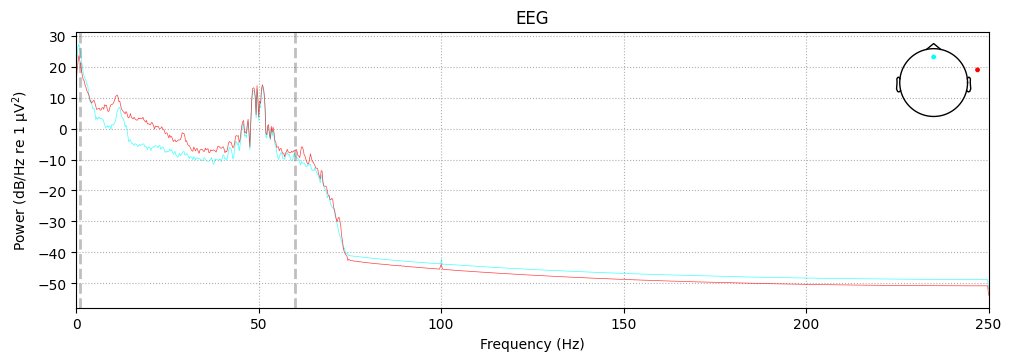

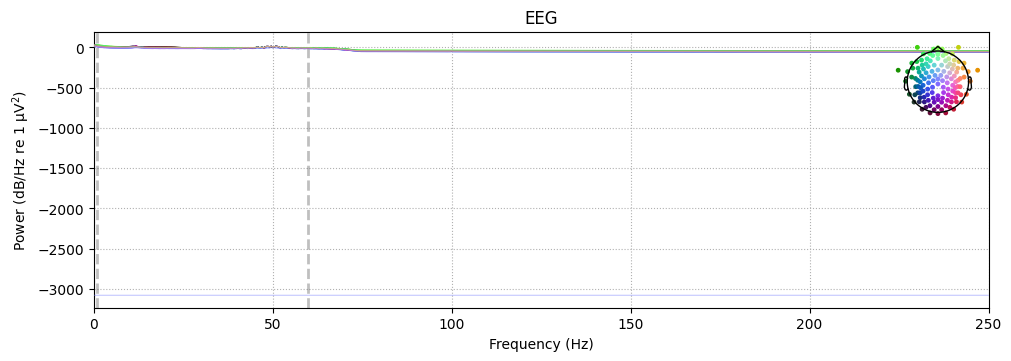

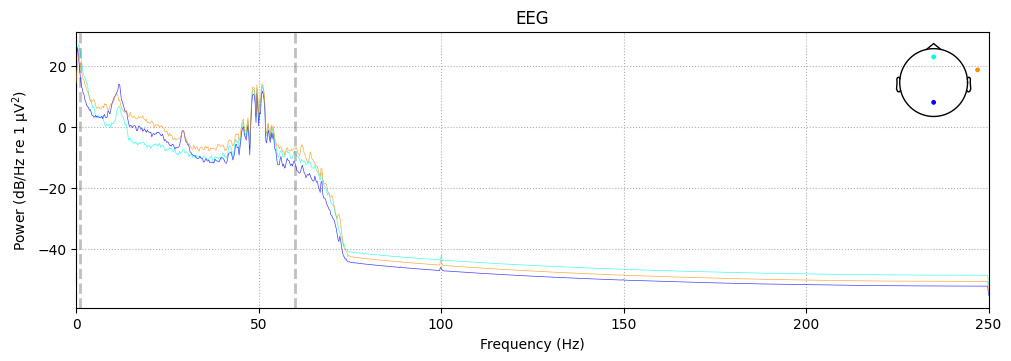

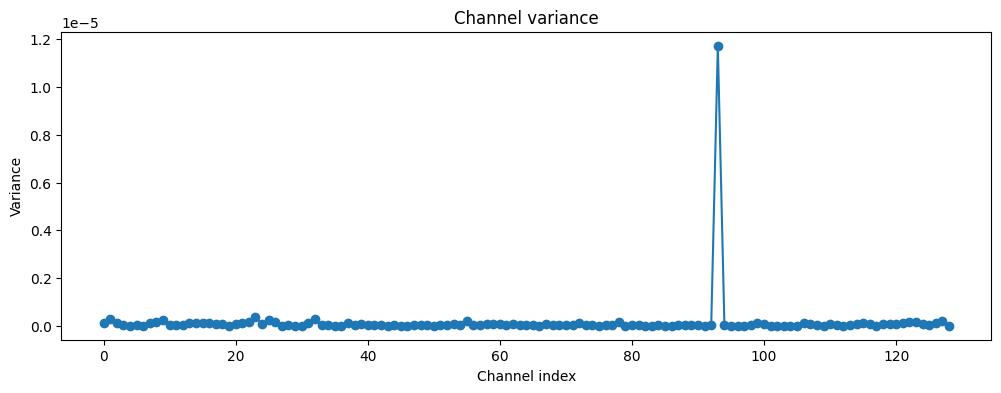

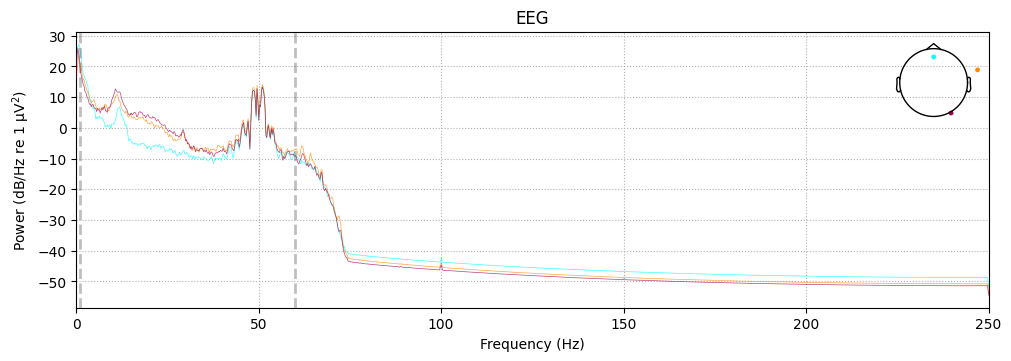

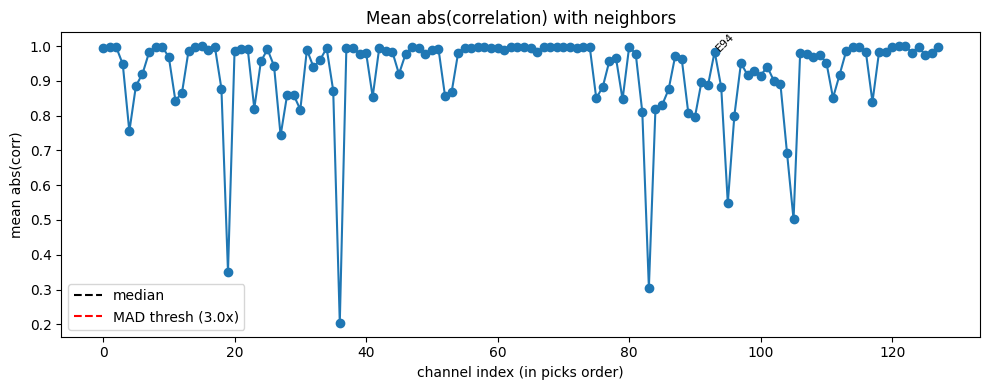

Plotting PSD and timeseries for top candidates: ['E94']
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


/Users/kavinfidel/Documents/Fidel/CNS_Lab/VM_EEG/.venv/lib/python3.13/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


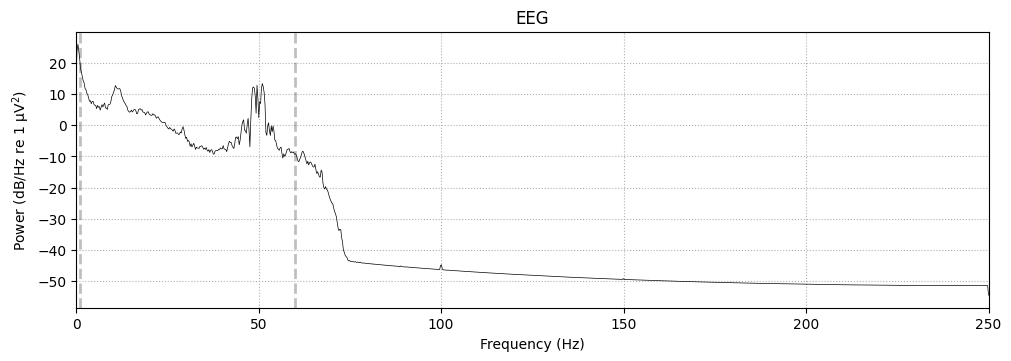

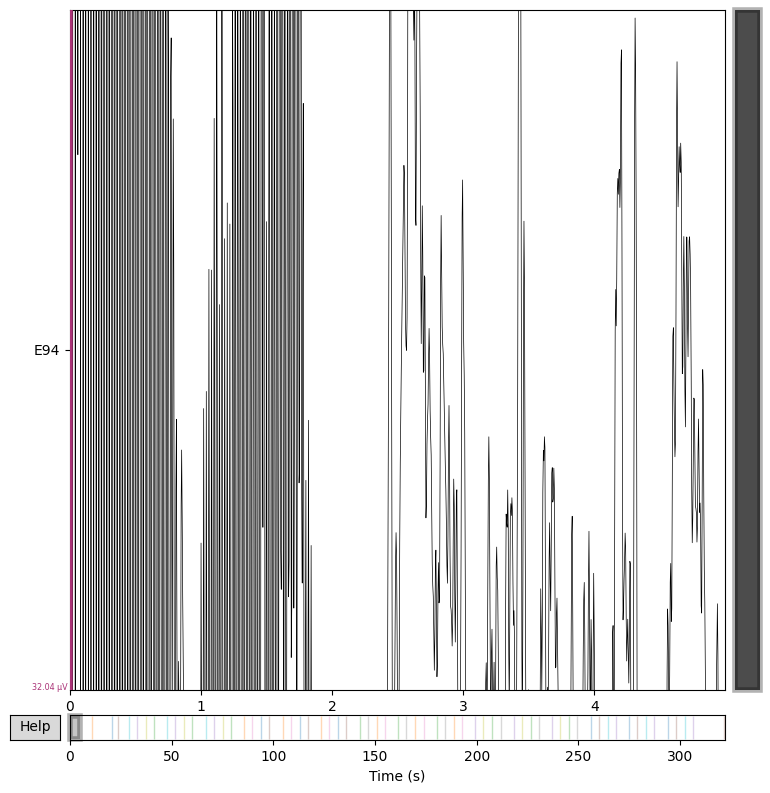

Marked bads now: ['E94']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 99.3 mm
Computing interpolation matrix from 128 sensor positions
Interpolating 1 sensors


<RawMff | signal1.bin, 152 x 161030 (322.1 s), ~186.9 MiB, data loaded>

In [23]:
res = detect_bad_channels_neighbor_correlation(file)

# Inspect results:
res['variance_bads']            # e.g. ['E94'] — keep these
res['neighbor_corr_bads']      # many candidates; inspect top ranked

# If you confirm some are bad, add to info['bads']:
suspected = res['ranked_candidates'][:3]  # for example choose top 3 to inspect/mark
file.info['bads'].extend([ch for ch in suspected if ch not in file.info['bads']])
print("Marked bads now:", file.info['bads'])

# Optionally interpolate bads (in-place). It's best to do this after any filtering you want:
file.interpolate_bads(reset_bads=True)  # or reset_bads=False to keep them listed
